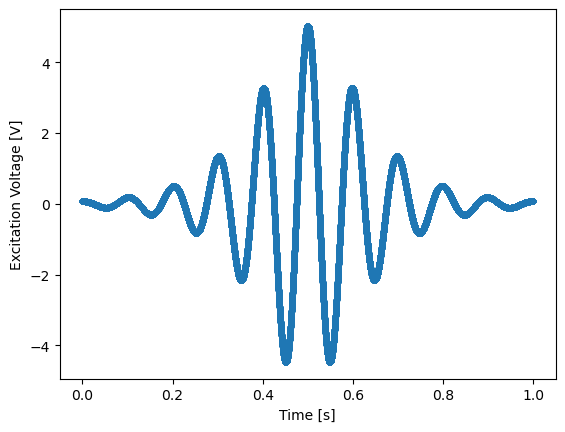

In [15]:

import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import sys
from pathlib import Path
# add Modeling/ to Python path
project_root = Path.cwd().parents[2]
sys.path.append(str(project_root))
from Modeling.models.beam_properties import PiezoBeamParams
import matplotlib.pyplot as plt

# from Modeling.models.ROM import ROM
import importlib
import Modeling.models.ROM as ROM_module

importlib.reload(ROM_module)
ROM = ROM_module.ROM


import numpy as np
from numpy import pi	
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from IPython.display import clear_output
from matplotlib import cm, colors
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
# -----------------------
# Time grid (FIXED STEP)
# -----------------------
t_end = 0.1
fs = 200_000          # 200 kHz sampling
# dt = 1 / fs


# -----------------------
# Chirped excitation
# -----------------------
A_exc = 20.0          # volts
f0 = 500              # Hz
f1 = 4000             # Hz
dt = 1e-5


# def v_exc(t):
# 	return A_exc * np.sin(
# 		2*np.pi * (f0 + (f1 - f0) * t / t_end) * t
# 	)

# def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
# 	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
t_end = 1
# tau2 = 0.5 * eps**2 * Q * phi0**2 
# tau1 = eps * phi0 * np.sqrt(Q / (2 * P)) * dOmega_dq[idx0]
# print("tau1= ", tau1, " tau2= ", tau2)
# print( " K_i= ", K_i,"K_p= ", K_p, " K_c= ", K_c, " R_c= ", R_c)
K_i = 60; K_c = 16e5; R_c = 1e3; K_p = 1e-5
f_exc = 10
t_eval = np.arange(0, t_end, dt)
def v_exc(t, A_exc=5, f_exc=f_exc, t_end=t_end, tau1= 10, tau2=0.01):
	# t = t/t0
	tc = t_end / 2
	t = t #- tc
	envelope = 1 / np.cosh(5+ -tau1 * t) * np.exp(tau2 * t)
	return A_exc * envelope * np.cos(2*np.pi*f_exc*t)

t_eval = np.arange(0, t_end, 1e-5)
plt.figure()
plt.plot(t_eval, v_exc(t_eval), '.-' )
plt.xlabel('Time [s]')
plt.ylabel('Excitation Voltage [V]')
plt.show()


In [16]:

# -----------------------
# Create ROM
# -----------------------
Q = 300
params = PiezoBeamParams(
	Q=Q, L_b=3.185
	)
rom = ROM(params, N=200)
x_eval = np.linspace(0, rom.p.L_b, 500)
# -----------------------
# Run time simulation
# -----------------------
out = rom.run_time_sim_jit(
	v_exc=v_exc,
	j_exc=299,
	R_c=R_c,
	K_c=K_c,
	K_p=K_p,
	K_i=K_i,
	t_eval=t_eval,
	x_eval=x_eval
)

t = out["t"]
veloc = out["veloc"]
x_eval = out["x_eval"]
plt.figure(figsize=(8,5))
plt.pcolormesh(
	t * 1e3,
	x_eval,
	veloc,
	shading="auto",
	cmap="seismic"
)
plt.xlabel("Time [ms]")
plt.ylabel("Position along beam [m]")
plt.colorbar(label="Velocity [m/s]")
plt.tight_layout()
plt.show()
# Create subplots for each time instance
n_times = len(t)
# Choose time instances: start, several intermediate times, and end
time_indices = np.linspace(0, n_times - 1, 20, dtype=int)
# time_indices = np.arange(0, 20)  # specific time indices
time_values = t[time_indices]

fig, axes = plt.subplots(len(time_indices), 1, figsize=(10, 3 * len(time_indices)))
if len(time_indices) == 1:
    axes = [axes]

for idx, (ax, t_idx) in enumerate(zip(axes, time_indices)):
    ax.plot(x_eval, veloc[:, t_idx], 'b-', linewidth=2)
    ax.set_ylabel('Velocity [m/s]')
    ax.set_title(f'Time t = {time_values[idx]:.3f} s')
    ax.grid(True)

axes[-1].set_xlabel('Position along beam [m]')
plt.tight_layout()
plt.show()

# Alternative: overlay all on same plot
plt.figure(figsize=(10, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_indices)))
for t_idx, color, t_val in zip(time_indices, colors, time_values):
    plt.plot(x_eval, veloc[:, t_idx], color=color, linewidth=2, label=f't = {t_val:.3f} s')
plt.xlabel('Position along beam [m]')
plt.ylabel('Velocity [m/s]')
plt.title('Velocity Profile Evolution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1m[1m[1mNo implementation of function Function(<built-in function getitem>) found for signature:
 
 >>> getitem(int64, int64)
 
There are 22 candidate implementations:
[1m  - Of which 22 did not match due to:
  Overload of function 'getitem': File: <numerous>: Line N/A.
    With argument(s): '(int64, int64)':[0m
[1m   No match.[0m
[0m
[0m[1mDuring: typing of intrinsic-call at c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\models\jit_stuff.py (21)[0m
[0m[1mDuring: typing of intrinsic-call at c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\models\jit_stuff.py (27)[0m
[0m[1mDuring: typing of intrinsic-call at c:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam\Modeling\models\jit_stuff.py (33)[0m
[0m[1mDuring: typing of intrinsic-call at c:\Users\setemadi3\GaTech Dropbox\Seyednima